<a href="https://colab.research.google.com/github/laurenkzz/2BI_InteligenciaArtificial/blob/main/ArvoreDecisao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("/Teen_Mental_Health_Dataset.csv")

In [3]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for coluna in df.select_dtypes(include="object").columns:
    df[coluna] = encoder.fit_transform(df[coluna])

In [4]:
print(df.dtypes)

age                           int64
gender                        int64
daily_social_media_hours    float64
platform_usage                int64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level      int64
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [5]:
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

arvore.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
y_pred = arvore.predict(X_test)

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Acurácia: 0.9916666666666667
Precisão: 0.8333333333333334
Recall: 0.8333333333333334
F1-Score: 0.8333333333333334


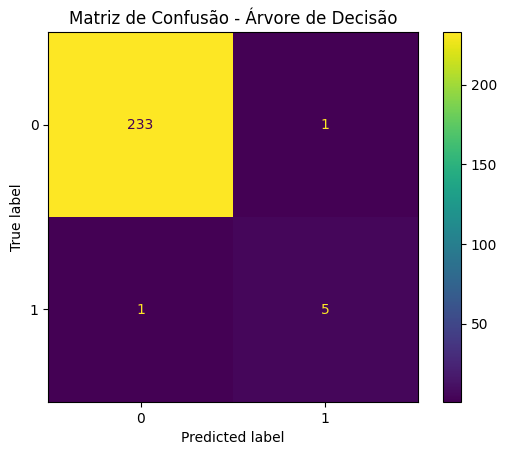

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

In [11]:
import pandas as pd

importancias = pd.DataFrame({
    "Atributo": X.columns,
    "Importancia": arvore.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print(importancias)

                    Atributo  Importancia
9               stress_level     0.418436
10             anxiety_level     0.285414
2   daily_social_media_hours     0.244328
4                sleep_hours     0.051821
3             platform_usage     0.000000
1                     gender     0.000000
0                        age     0.000000
5   screen_time_before_sleep     0.000000
7          physical_activity     0.000000
6       academic_performance     0.000000
8   social_interaction_level     0.000000
11           addiction_level     0.000000


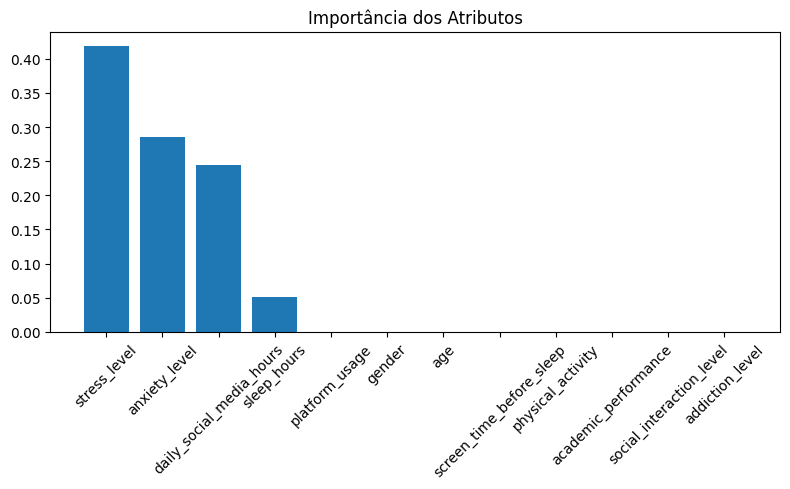

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    importancias["Atributo"],
    importancias["Importancia"]
)

plt.xticks(rotation=45)
plt.title("Importância dos Atributos")
plt.tight_layout()
plt.show()